In [67]:
"""Baseline market-neutral cross-sectional momentum study."""

from __future__ import annotations

import json

import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500

START_DATE = "2015-01-01"
END_DATE = "2023-12-31"
LOOKBACK = 120
SKIP = 21
SHIFT = 1
N_LONG = 25
N_SHORT = 25
REBALANCE_EVERY = 21

In [1]:
universe = qs.download(SP500, START_DATE, END_DATE)
benchmark = qs.download("SPY", START_DATE, END_DATE)

$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['SOLV', 'GEV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


sp500_market_neutral_xsect_momentum_v0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 51.95it/s, stage=metrics]


sharpe                             -0.270038
ann_return                         -0.043876
ann_vol                             0.133058
max_drawdown                       -0.390644
max_drawdown_duration                   2004
max_drawdown_start       2016-01-14 00:00:00
max_drawdown_end         2023-12-29 00:00:00
avg_daily_turnover                  0.164011
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                     -0.077536
information_ratio                  -0.703482


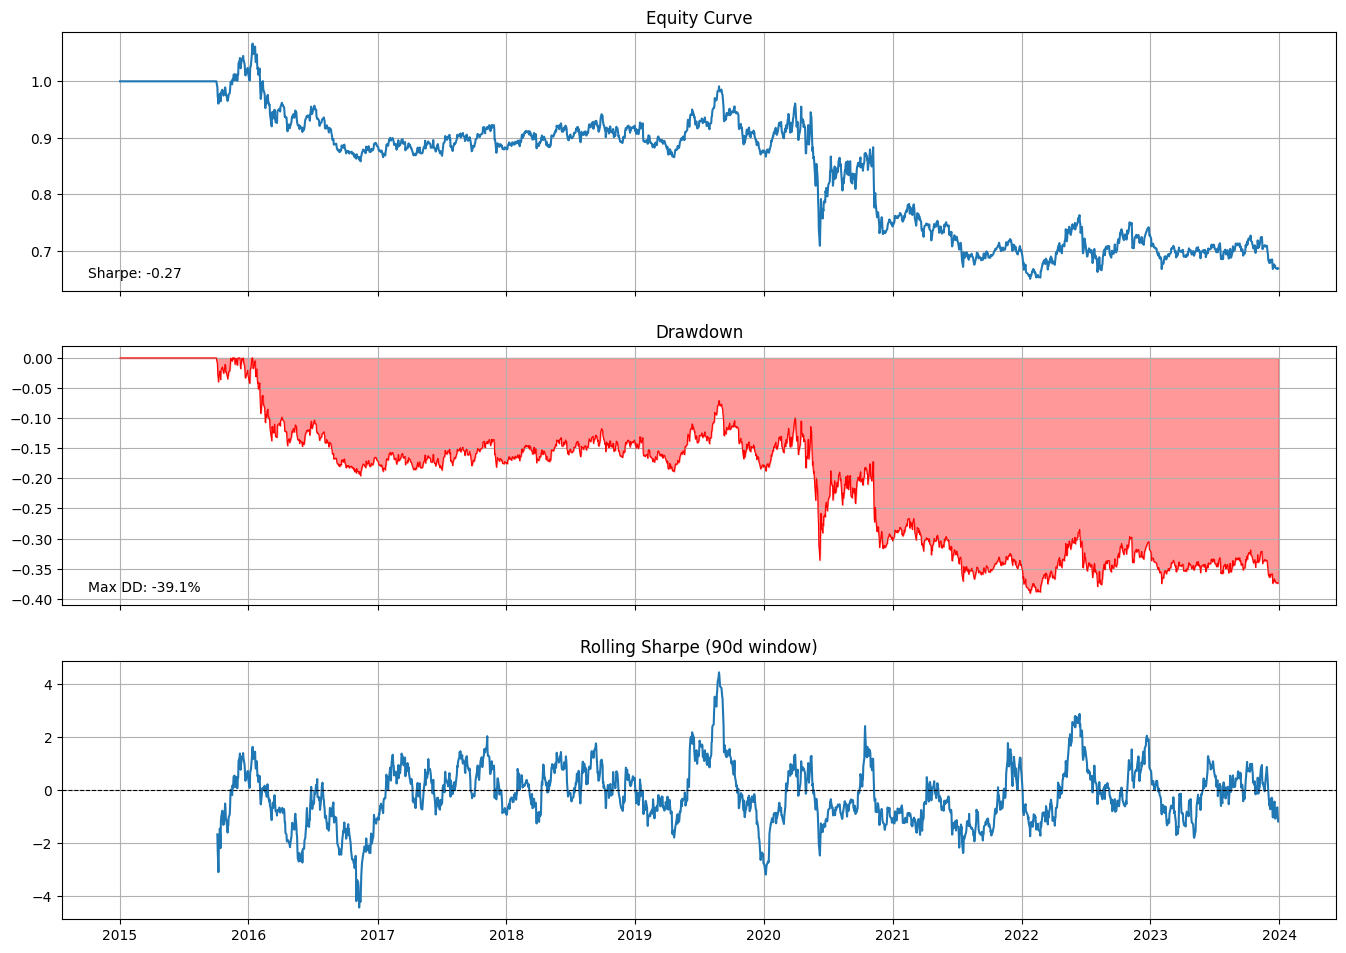

Study(name='sp500_market_neutral_xsect_momentum_v0', steps=['base_signal', 'position_builder', 'position_scaler'], weighting=False, ran=True)

In [68]:
def momentum_signal(**cache):
    log_returns = cache["log_returns"]
    return log_returns.shift(SKIP).rolling(LOOKBACK).sum().shift(SHIFT)


study = (
    Study(
        universe=universe,
        
        benchmark=benchmark,
        name="sp500_market_neutral_xsect_momentum_v0",
    )
    .base_signal(momentum_signal)
    .build_long_short(n_long=N_LONG, n_short=N_SHORT)
    .rebalance(every=REBALANCE_EVERY)
    .run()
)
study.report()